In [1]:
!pip -q install -U diffusers transformers accelerate safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 106.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 108.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.3/637.3 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 111.2 MB/s eta 0:00:0000:01


In [20]:
import os
import gc
import csv
import glob
import random
import shutil

import torch
import matplotlib.pyplot as plt

from PIL import Image
from diffusers import StableDiffusionPipeline, StableDiffusionXLPipeline

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ─── 批次控制 ────────────────────────────────────────────
BATCH_ID   = 4          # ← 每批改这里：0, 1, 2, ... 9
BATCH_SIZE = 125        # 每个模型每批生成数量
BASE_SEED  = BATCH_ID * 10000   # 每批 seed 自动偏移，保证不重复
# ─────────────────────────────────────────────────────────

random.seed(BASE_SEED)
torch.manual_seed(BASE_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(BASE_SEED)

BASE_DIR       = "/kaggle/working/anime_fake_v1"
ANYTHING_DIR   = os.path.join(BASE_DIR, "anything_v5")
ANIMAGINE_DIR  = os.path.join(BASE_DIR, "animagine_xl_3_1")
META_DIR       = os.path.join(BASE_DIR, "metadata")

os.makedirs(ANYTHING_DIR,  exist_ok=True)
os.makedirs(ANIMAGINE_DIR, exist_ok=True)
os.makedirs(META_DIR,      exist_ok=True)

print("Output dir:", BASE_DIR)
print(f"Batch {BATCH_ID} | seed offset {BASE_SEED} | {BATCH_SIZE} images/model")

DEVICE: cuda
Output dir: /kaggle/working/anime_fake_v1
Batch 4 | seed offset 40000 | 125 images/model


In [21]:
import random

# ============================================================
# 原有工具函数（保持不变）
# ============================================================
def save_image(img: Image.Image, save_path: str, final_size=(512, 512), jpg_quality=95):
    img = img.convert("RGB")
    img = img.resize(final_size)
    img.save(save_path, format="JPEG", quality=jpg_quality)

def init_csv(csv_path):
    if not os.path.exists(csv_path):
        with open(csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["filename", "model", "seed", "prompt", "negative_prompt"])

def append_csv(csv_path, row):
    with open(csv_path, "a", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(row)

def show_samples(folder, n=4):
    files = sorted(glob.glob(os.path.join(folder, "*.jpg")))[:n]
    if not files:
        print(f"No images found in {folder}")
        return
    plt.figure(figsize=(4 * n, 4))
    for idx, f in enumerate(files, 1):
        img = Image.open(f)
        plt.subplot(1, n, idx)
        plt.imshow(img)
        plt.axis("off")
        plt.title(os.path.basename(f))
    plt.tight_layout()
    plt.show()

# ============================================================
# 新的 Prompt 系统
# ============================================================
style_tiers = {
    "retro_tv": {
        "templates": [
            "2000s TV anime style, cel shading, flat color, bold outlines, anime screenshot",
            "classic anime style, retro coloring, simple cel shading, bold outlines",
            "90s anime style, flat cel shading, clean lineart, limited color palette",
        ],
        "negative": (
            "modern digital painting, ultra detailed, complex shading, "
            "photorealistic, 3d, full body, nsfw, watermark, blurry, deformed"
        )
    },
    "modern_vn": {
        "templates": [
            "visual novel CG style, soft shading, detailed hair highlight, gradient background",
            "bishoujo game illustration, modern anime coloring, smooth shading, clean lineart",
            "anime game CG, soft lighting, detailed eyes, pastel color scheme",
        ],
        "negative": (
            "photorealistic, 3d, retro anime, flat color, "
            "full body, nsfw, watermark, blurry, deformed, bad anatomy"
        )
    },
    "pixiv_illust": {
        "templates": [
            "anime illustration, detailed shading, soft rim lighting, colored background",
            "high quality anime fanart, detailed eyes, painterly shading, dynamic lighting",
            "anime portrait illustration, detailed hair, soft focus background, rich color",
        ],
        "negative": (
            "photorealistic, 3d, simple background, flat color, "
            "full body, nsfw, watermark, blurry, deformed, bad anatomy"
        )
    }
}

MODEL_TIER_MAP = {
    "anything_v5": ["modern_vn", "modern_vn", "pixiv_illust", "pixiv_illust", "retro_tv"],
    "animagine":   ["retro_tv", "retro_tv", "modern_vn", "modern_vn", "pixiv_illust"],
}

female_hair_colors = [
    "brown hair", "black hair", "blonde hair", "silver hair", "white hair",
    "blue hair", "purple hair", "pink hair", "orange hair", "dark red hair",
    "teal hair", "light brown hair"
]
female_hair_styles = [
    "long hair", "short hair", "twintails", "ponytail", "bob cut",
    "hime cut", "side ponytail", "messy hair", "braided hair",
    "wavy hair", "straight hair"
]
female_outfits = [
    "school uniform", "sailor uniform", "simple dress", "cardigan",
    "blouse", "fantasy costume", "kimono", "casual clothes",
    "ribbon tie outfit", "winter coat"
]
male_hair_colors = [
    "black hair", "brown hair", "blonde hair", "silver hair",
    "dark blue hair", "white hair"
]
male_hair_styles = [
    "short hair", "messy hair", "swept back hair",
    "undercut", "spiky hair", "medium length hair"
]
male_outfits = [
    "school uniform", "blazer", "casual jacket",
    "fantasy armor", "simple shirt", "hoodie"
]
eye_colors = [
    "blue eyes", "green eyes", "brown eyes",
    "purple eyes", "red eyes", "golden eyes", "teal eyes"
]
expressions = [
    "gentle smile", "neutral expression", "calm expression",
    "slight smile", "serious expression", "surprised expression",
    "shy expression", "confident expression"
]
compositions = [
    "bust-up portrait, looking at viewer, centered composition",
    "upper body portrait, slight angle, looking at viewer",
    "close-up face shot, looking at viewer",
    "head and shoulders, three-quarter view",
    "bust-up, slight downward gaze",
    "portrait, looking slightly to the side",
]

def build_prompt(model_name: str) -> tuple:
    tier_name = random.choice(MODEL_TIER_MAP[model_name])
    tier = style_tiers[tier_name]
    is_male = random.random() < 0.15
    if is_male:
        role       = "1boy"
        hair_color = random.choice(male_hair_colors)
        hair_style = random.choice(male_hair_styles)
        outfit     = random.choice(male_outfits)
    else:
        role       = "1girl"
        hair_color = random.choice(female_hair_colors)
        hair_style = random.choice(female_hair_styles)
        outfit     = random.choice(female_outfits)
    prompt = ", ".join([
        random.choice(tier["templates"]),
        role, hair_color, hair_style,
        random.choice(eye_colors),
        random.choice(expressions),
        outfit,
        random.choice(compositions),
        "solo",
    ])
    return prompt, tier["negative"]

def build_prompt_anything():
    return build_prompt("anything_v5")

def build_prompt_animagine():
    return build_prompt("animagine")

In [22]:
anything_csv = os.path.join(META_DIR, "anything_v5_prompts.csv")
init_csv(anything_csv)

pipe_anything = StableDiffusionPipeline.from_pretrained(
    "stablediffusionapi/anything-v5",
    torch_dtype=torch.float16,
    safety_checker=None
).to(DEVICE)
pipe_anything.set_progress_bar_config(disable=False)

# 断点续传：从已有文件数继续编号
start_i = len(glob.glob(os.path.join(ANYTHING_DIR, "*.jpg")))
print(f"[Anything-v5] already have {start_i} images, generating {BATCH_SIZE} more...")

for i in range(start_i, start_i + BATCH_SIZE):
    try:
        prompt, negative_prompt = build_prompt_anything()
        seed_i  = BASE_SEED + i
        generator = torch.Generator(device=DEVICE).manual_seed(seed_i)

        image = pipe_anything(
            prompt=prompt,
            negative_prompt=negative_prompt,
            num_inference_steps=30,
            guidance_scale=7.0,
            width=512,
            height=512,
            generator=generator
        ).images[0]

        filename  = f"anything_{i:04d}.jpg"
        save_path = os.path.join(ANYTHING_DIR, filename)
        save_image(image, save_path)
        append_csv(anything_csv, [filename, "anything-v5", seed_i, prompt, negative_prompt])
        print(f"[Anything-v5] {i - start_i + 1}/{BATCH_SIZE}  saved: {filename}")

    except Exception as e:
        print(f"[Anything-v5] SKIP i={i}, error: {e}")
        continue


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stablediffusionapi--anything-v5/snapshots/095f2abb647d239d7988e34ea236d20153f11573/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

[Anything-v5] already have 250 images, generating 125 more...


...

[Anything-v5] 123/125  saved: anything_0372.jpg


  0%|          | 0/30 [00:00<?, ?it/s]

[Anything-v5] 124/125  saved: anything_0373.jpg


  0%|          | 0/30 [00:00<?, ?it/s]

[Anything-v5] 125/125  saved: anything_0374.jpg


In [23]:
del pipe_anything
gc.collect()
torch.cuda.empty_cache()
print("Anything-v5 pipeline cleared.")

Anything-v5 pipeline cleared.


In [24]:
animagine_csv = os.path.join(META_DIR, "animagine_xl_3_1_prompts.csv")
init_csv(animagine_csv)

pipe_animagine = StableDiffusionXLPipeline.from_pretrained(
    "cagliostrolab/animagine-xl-3.1",
    torch_dtype=torch.float16,
    use_safetensors=True
).to(DEVICE)
pipe_animagine.set_progress_bar_config(disable=False)

# 断点续传
start_i = len(glob.glob(os.path.join(ANIMAGINE_DIR, "*.jpg")))
print(f"[Animagine XL] already have {start_i} images, generating {BATCH_SIZE} more...")

for i in range(start_i, start_i + BATCH_SIZE):
    try:
        prompt, negative_prompt = build_prompt_animagine()
        seed_i  = BASE_SEED + 50000 + i   # animagine 独立 seed 空间
        generator = torch.Generator(device=DEVICE).manual_seed(seed_i)

        image = pipe_animagine(
            prompt=prompt,
            negative_prompt=negative_prompt,
            num_inference_steps=30,
            guidance_scale=6.0,
            width=832,
            height=832,
            generator=generator
        ).images[0]

        filename  = f"animagine_{i:04d}.jpg"
        save_path = os.path.join(ANIMAGINE_DIR, filename)
        save_image(image, save_path)
        append_csv(animagine_csv, [filename, "animagine-xl-3.1", seed_i, prompt, negative_prompt])
        print(f"[Animagine XL] {i - start_i + 1}/{BATCH_SIZE}  saved: {filename}")

    except Exception as e:
        print(f"[Animagine XL] SKIP i={i}, error: {e}")
        continue


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[Animagine XL] already have 250 images, generating 125 more...


  0%|          | 0/30 [00:00<?, ?it/s]

...

[Animagine XL] 123/125  saved: animagine_0372.jpg


  0%|          | 0/30 [00:00<?, ?it/s]

[Animagine XL] 124/125  saved: animagine_0373.jpg


  0%|          | 0/30 [00:00<?, ?it/s]

[Animagine XL] 125/125  saved: animagine_0374.jpg


Animagine XL pipeline cleared.


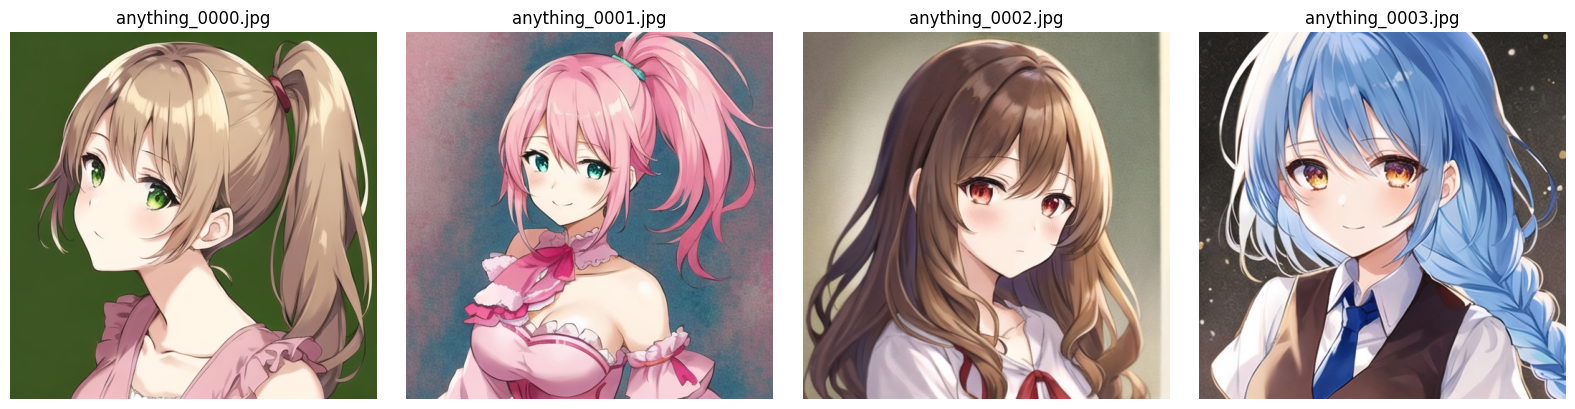

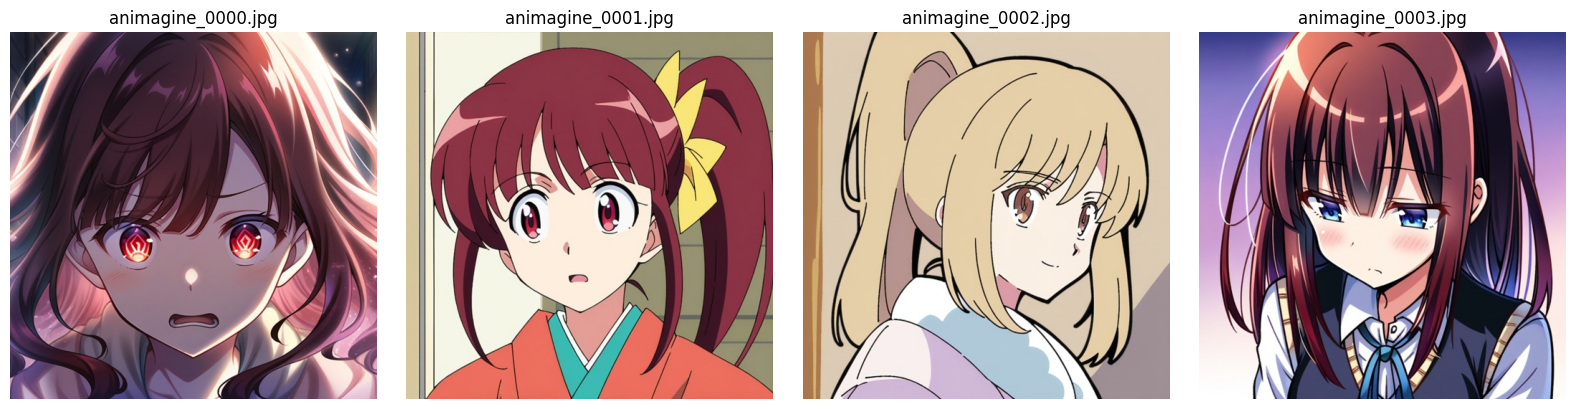

In [25]:
del pipe_animagine
gc.collect()
torch.cuda.empty_cache()
print("Animagine XL pipeline cleared.")

show_samples(ANYTHING_DIR,  n=4)
show_samples(ANIMAGINE_DIR, n=4)

In [26]:
for root, dirs, files in os.walk(BASE_DIR):
    level = root.replace(BASE_DIR, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 2 * (level + 1)
    for f in files[:10]:
        print(f"{subindent}{f}")
        
n_anything  = len(glob.glob(os.path.join(ANYTHING_DIR,  "*.jpg")))
n_animagine = len(glob.glob(os.path.join(ANIMAGINE_DIR, "*.jpg")))
print(f"\nTotal: {n_anything + n_animagine} / 2500")

anime_fake_v1/
  metadata/
    animagine_xl_3_1_prompts.csv
    anything_v5_prompts.csv
  animagine_xl_3_1/
    animagine_0290.jpg
    animagine_0301.jpg
    animagine_0149.jpg
    animagine_0311.jpg
    animagine_0083.jpg
    animagine_0159.jpg
    animagine_0035.jpg
    animagine_0197.jpg
    animagine_0323.jpg
    animagine_0041.jpg
  anything_v5/
    anything_0323.jpg
    anything_0138.jpg
    anything_0056.jpg
    anything_0169.jpg
    anything_0215.jpg
    anything_0202.jpg
    anything_0217.jpg
    anything_0144.jpg
    anything_0143.jpg
    anything_0241.jpg

Total: 750 / 2500


In [27]:
zip_path = f"/kaggle/working/anime_fake_v1_batch{BATCH_ID:02d}"
zip_file = shutil.make_archive(zip_path, "zip", BASE_DIR)
print("ZIP created:", zip_file)

ZIP created: /kaggle/working/anime_fake_v1_batch04.zip


In [28]:
print("Done.")
print("Images folder:", BASE_DIR)
print("Zip file:", f"/kaggle/working/anime_fake_v1_batch{BATCH_ID:02d}.zip")
print("You can download them from the Kaggle Output panel.")

Done.
Images folder: /kaggle/working/anime_fake_v1
Zip file: /kaggle/working/anime_fake_v1_batch04.zip
You can download them from the Kaggle Output panel.
